# Lab 03: Image Classification Model - Fashion-MNIST
**Workflow Overview**

- **Stage 1 – Data Ingestion**: Load raw `.idx` data → verify shape and pixel range
- **Stage 2 – Data Quality Check**: Check missing values, duplicates, pixel bounds, blank images → clean dataset
- **Stage 3 – Descriptive Analysis**: Compute statistics (mean, std) + verify class balance
- **Stage 4 – Visual EDA & Dimensionality Reduction**: Sample images, mean images. PCA (linear) + t-SNE, UMAP, PyMDE (non-linear) → analyze structure & class separability
- **Stage 5 – Data Distribution & Export**: Export Train-Test + label mapping


## 1. Data Ingestion and Structural Inspection

In this initial stage, we establish the foundation for our project. We will import the necessary libraries, define custom functions to handle the specific binary format of the Fashion-MNIST dataset, and verify the structural integrity of the data.

### 1.1 Environment Setup & Library Imports

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import time
import umap
import pymde

# Setting visual styles for the project
%matplotlib inline
sns.set_theme(style="whitegrid")

### 1.2 Loading Data and Structural Inspection
We load the data from the local directory. To prove that the data is entirely raw and unprocessed, we will inspect the shape of the arrays and the maximum pixel intensity. As expected for unflattened, unnormalized images, the shape should be `(n_samples, 784)` and the pixel values should range up to `255`.

In [13]:
def read_idx_images(filename):
    """Parses idx-ubyte image files into numpy arrays."""
    with open(filename, 'rb') as f:
        # Header for images is 16 bytes
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
    # Each image is 28x28 = 784 pixels
    return data.reshape(-1, 784)

def read_idx_labels(filename):
    """Parses idx-ubyte label files into numpy arrays."""
    with open(filename, 'rb') as f:
        # Header for labels is 8 bytes
        return np.frombuffer(f.read(), dtype=np.uint8, offset=8)

# Define the local path to the data folder
data_path = 'data/raw' 

# Load raw training and testing sets
X_train_raw = read_idx_images(os.path.join(data_path, 'train-images-idx3-ubyte'))
y_train_raw = read_idx_labels(os.path.join(data_path, 'train-labels-idx1-ubyte'))
X_test_raw  = read_idx_images(os.path.join(data_path, 't10k-images-idx3-ubyte'))
y_test_raw  = read_idx_labels(os.path.join(data_path, 't10k-labels-idx1-ubyte'))

print("--- RAW DATA STRUCTURE ---")
print(f"Training Data Shape: {X_train_raw.shape}")
print(f"Testing Data Shape : {X_test_raw.shape}")
print(f"Max Raw Pixel Value: {X_train_raw.max()} (Expected 255 for unnormalized data)")
print(f"Min Raw Pixel Value: {X_train_raw.min()} (Expected 0 for black background)")

--- RAW DATA STRUCTURE ---
Training Data Shape: (60000, 784)
Testing Data Shape : (10000, 784)
Max Raw Pixel Value: 255 (Expected 255 for unnormalized data)
Min Raw Pixel Value: 0 (Expected 0 for black background)


### 1.3 Raw Sample Visualization
To confirm the images were parsed correctly, we will display a few samples. Since our current data consists of flat 784-element vectors, we temporarily reshape individual samples to `28x28` matrices *only* within the plotting function.

In [14]:
# Mapping labels to class names
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Displaying the class mapping for documentation
class_mapping = pd.DataFrame({
    'Label': range(10),
    'Description': class_names
})
print("--- CLASS MAPPING ---")
print(class_mapping.to_string(index=False))

--- CLASS MAPPING ---
 Label Description
     0 T-shirt/top
     1     Trouser
     2    Pullover
     3       Dress
     4        Coat
     5      Sandal
     6       Shirt
     7     Sneaker
     8         Bag
     9  Ankle boot


## 2. Data Cleansing and Quality Assurance

Data cleansing is a crucial step to ensure the reliability of our machine learning models. In this stage, we will rigorously test the dataset for technical anomalies, such as missing values, duplicated records, and out-of-bounds pixel intensities.

### 2.1 Missing Value Analysis
We first check for `NaN` (Not a Number) or null values within our feature matrices. Missing data in image pixels would require either imputation strategies or the removal of corrupted samples.

In [15]:
print("--- MISSING VALUE CHECK ---")

# Check for any null values in the raw training and testing sets
train_nans = np.isnan(X_train_raw).sum()
test_nans = np.isnan(X_test_raw).sum()

print(f"Total missing values in Training set: {train_nans}")
print(f"Total missing values in Testing set : {test_nans}")

--- MISSING VALUE CHECK ---
Total missing values in Training set: 0
Total missing values in Testing set : 0


### 2.2 Duplicate Detection
Duplicate images can inadvertently cause data leakage or artificially bias the model towards specific samples. We use the `pandas` library to efficiently scan the 784-dimensional space for exact row matches.

In [16]:
print("--- DUPLICATE DETECTION ---")

# Convert the numpy arrays to pandas DataFrames for an efficient row-wise duplicate check
df_train = pd.DataFrame(X_train_raw)
df_test = pd.DataFrame(X_test_raw)

train_duplicates = df_train.duplicated().sum()
test_duplicates = df_test.duplicated().sum()

print(f"Number of extract duplicate rows in the Testing set: {test_duplicates}")
print(f"Number of exact duplicate rows in the Training set: {train_duplicates}")

--- DUPLICATE DETECTION ---
Number of extract duplicate rows in the Testing set: 0
Number of exact duplicate rows in the Training set: 0


### 2.3 Integrity Constraint Check (Pixel Boundaries)
To mathematically confirm that our data is valid 8-bit grayscale imagery, we must verify that no pixel value falls outside the expected `[0, 255]` boundary.

In [17]:
print("--- PIXEL INTEGRITY CHECK ---")

# Calculate global minimum and maximum across the entire training matrix
global_min = X_train_raw.min()
global_max = X_train_raw.max()

print(f"Global Minimum Pixel Value: {global_min}")
print(f"Global Maximum Pixel Value: {global_max}")

if global_min >= 0 and global_max <= 255:
    print("\nResult: All pixel values strictly adhere to the expected [0, 255] integer range.")
else:
    print("\nWarning: Out-of-bounds pixel values detected! Data corruption may have occurred.")

--- PIXEL INTEGRITY CHECK ---
Global Minimum Pixel Value: 0
Global Maximum Pixel Value: 255

Result: All pixel values strictly adhere to the expected [0, 255] integer range.


In [18]:
print("--- STRUCTURAL OUTLIER CHECK ---")

# Check if there is any row where ALL 784 pixels are exactly 0 (completely black image)
blank_train_images = np.sum(np.all(X_train_raw == 0, axis=1))
blank_test_images = np.sum(np.all(X_test_raw == 0, axis=1))

print(f"Completely blank images in Training set: {blank_train_images}")
print(f"Completely blank images in Testing set : {blank_test_images}")

--- STRUCTURAL OUTLIER CHECK ---
Completely blank images in Training set: 0
Completely blank images in Testing set : 0


## 3. Descriptive Statistics and Feature Analysis

Before applying advanced transformations or feeding data into machine learning algorithms, it is essential to analyze the statistical properties of the dataset. This stage explores the global pixel distributions and verifies the class balance, which directly influences our choice of evaluation metrics.

### 3.1 Global Pixel Statistics
We calculate the mean and standard deviation of the raw pixel intensities. Because Fashion-MNIST images consist of clothing items centered on a large black background, we expect the global average pixel value to be relatively low.

In [19]:
print("--- GLOBAL PIXEL STATISTICS ---")

# Calculate global mean and standard deviation across all 60,000 images
global_mean = X_train_raw.mean()
global_std = X_train_raw.std()

print(f"Global Mean Pixel Intensity: {global_mean:.2f} (out of 255)")
print(f"Global Standard Deviation  : {global_std:.2f}")

# Calculate the mean intensity for each individual image to see the spread
image_means = np.mean(X_train_raw, axis=1)
print(f"Darkest image average intensity : {image_means.min():.2f}")
print(f"Brightest image average intensity: {image_means.max():.2f}")

# Insight for report: A low global mean (~72.9) confirms that the majority 
# of the image space is occupied by the dark background (value 0).

--- GLOBAL PIXEL STATISTICS ---
Global Mean Pixel Intensity: 72.94 (out of 255)
Global Standard Deviation  : 90.02
Darkest image average intensity : 4.94
Brightest image average intensity: 191.82


### 3.2 Class Balance Verification
In machine learning, an imbalanced dataset can cause a model to heavily favor the majority class, leading to poor generalization. We must verify the distribution of our 10 clothing categories in the training set.

--- CLASS DISTRIBUTION ANALYSIS ---


C:\Users\thanh\AppData\Local\Temp\ipykernel_17732\3398319852.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y_train_raw, palette='viridis')


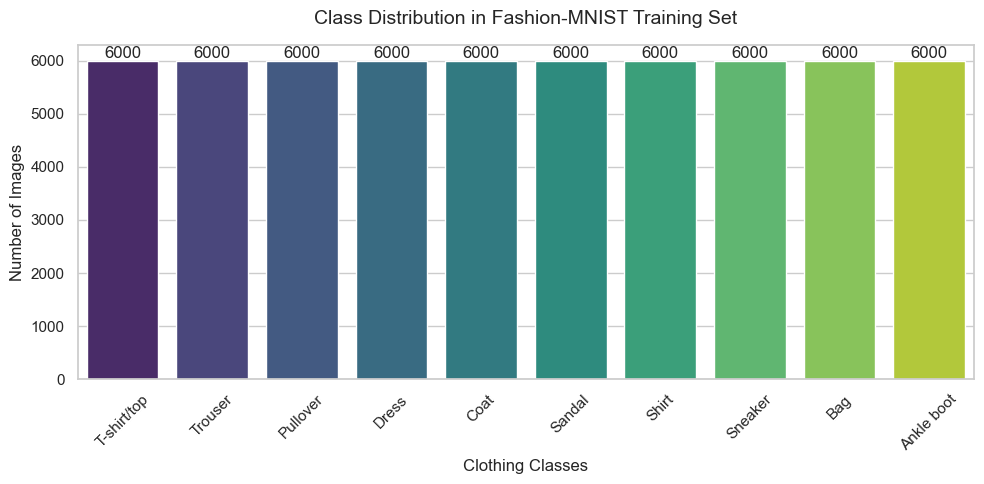

In [20]:
print("--- CLASS DISTRIBUTION ANALYSIS ---")

plt.figure(figsize=(10, 5))

# Plotting the frequency of each label in the training set
ax = sns.countplot(x=y_train_raw, palette='viridis')

plt.title('Class Distribution in Fashion-MNIST Training Set', fontsize=14, pad=15)
plt.xlabel('Clothing Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Replace numeric x-ticks with human-readable class names
plt.xticks(ticks=range(10), labels=class_names, rotation=45)

# Add exact count labels on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### 3.3 Image Intensity Distribution
To understand how pixel values are spread across the dataset, we plot a histogram. This will help us visually confirm the dominance of the background and the variance of the foreground clothing features.

--- PIXEL INTENSITY DISTRIBUTION ---


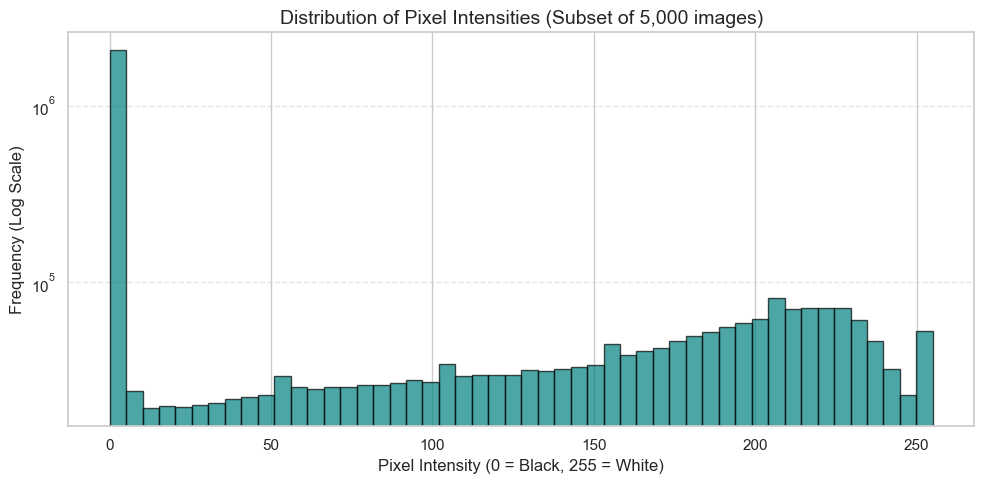

In [21]:
print("--- PIXEL INTENSITY DISTRIBUTION ---")

plt.figure(figsize=(10, 5))

# Flatten a subset of the data (e.g., 5000 images) to save memory/time while plotting
subset_pixels = X_train_raw[:5000].flatten()

# Plot histogram with 50 bins
plt.hist(subset_pixels, bins=50, color='teal', alpha=0.7, edgecolor='black')

plt.title('Distribution of Pixel Intensities (Subset of 5,000 images)', fontsize=14)
plt.xlabel('Pixel Intensity (0 = Black, 255 = White)', fontsize=12)
plt.ylabel('Frequency (Log Scale)', fontsize=12)

# Use a logarithmic scale for the Y-axis because the background pixels (0) 
# will vastly outnumber the clothing pixels (>0).
plt.yscale('log')
plt.grid(axis='y', alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

# Insight for report: The massive spike at 0 represents the black background. 
# The rest of the distribution represents the varying shades of gray that make up the clothing.

## 4. Advanced Visual Exploratory Data Analysis

While basic statistics provide a high-level overview, visual EDA allows us to uncover hidden patterns within the spatial structure of the images. In this stage, we will visualize the "average" item of each class and map our high-dimensional data into a 2D space to observe class separability.

### 4.1 Visualizing a Gallery of Samples per Class
Before applying advanced dimensionality reduction techniques, it is crucial to visually inspect the raw data to understand intra-class variance and inter-class similarity. 

Below, we plot a comprehensive 10x10 gallery featuring 10 random samples for each of the 10 clothing categories in the Fashion-MNIST dataset.

--- VISUALIZING 10 SAMPLES PER CLASS ---


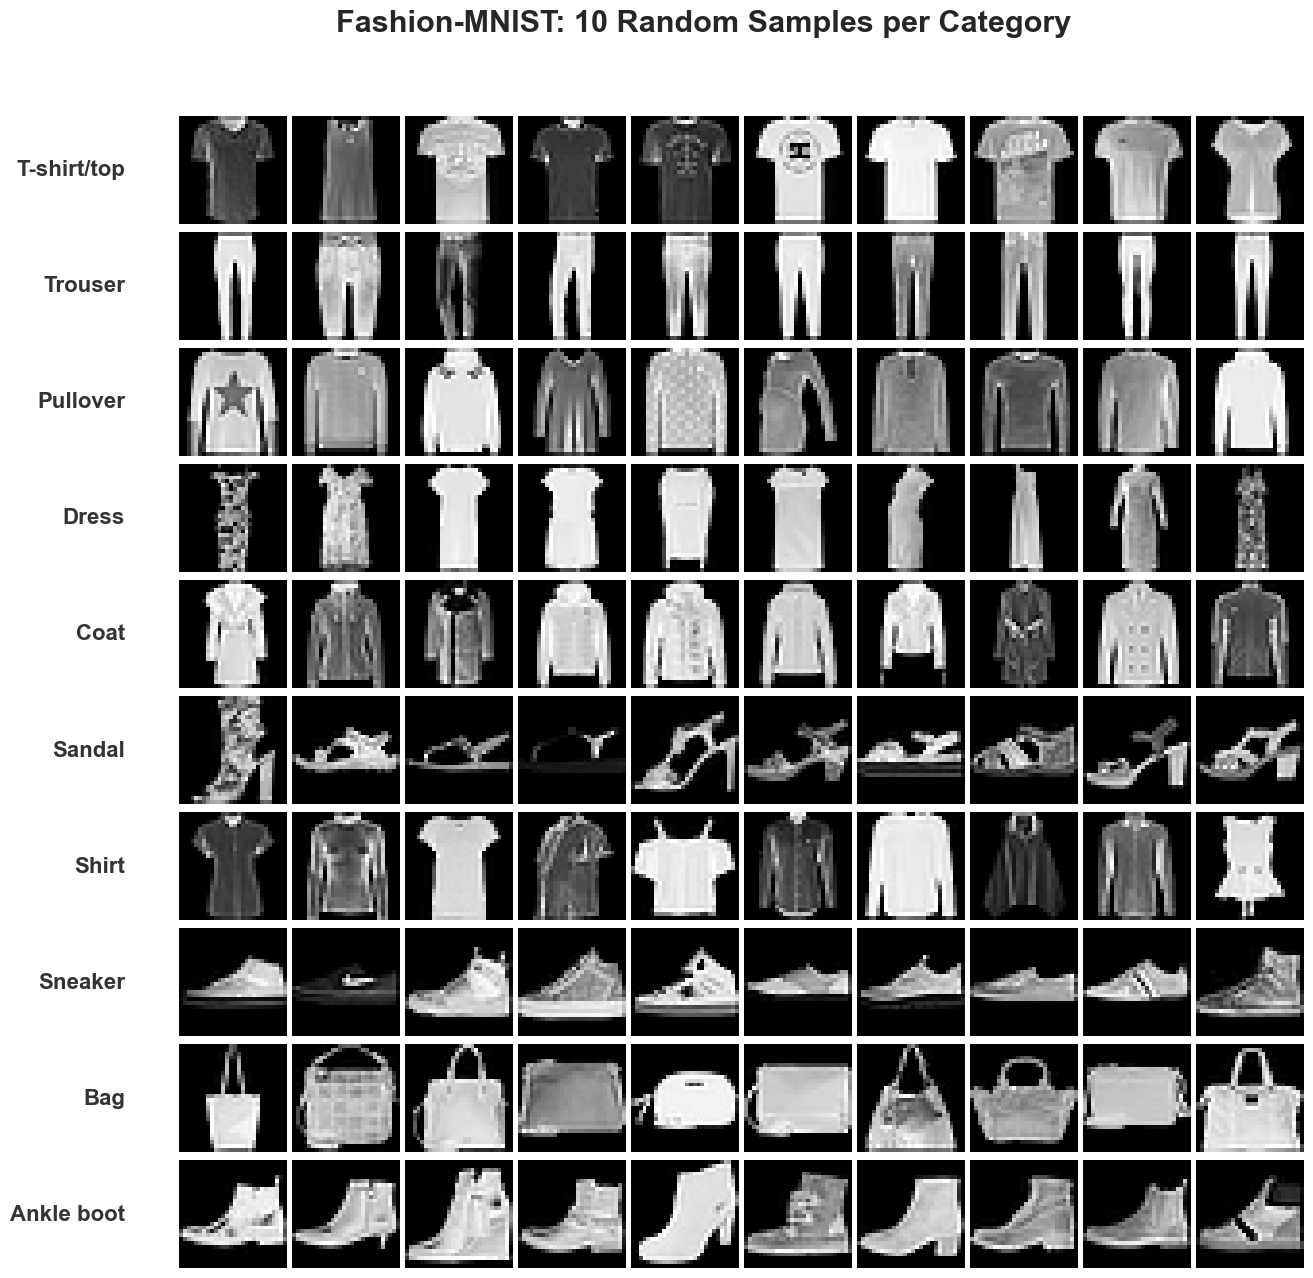

In [22]:
print("--- VISUALIZING 10 SAMPLES PER CLASS ---")

# Define the grid size: 10 classes (rows) x 10 samples (columns)
num_classes = 10
samples_per_class = 10

# Create a larger figure to accommodate 100 images
fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(15, 15))
fig.suptitle("Fashion-MNIST: 10 Random Samples per Category", 
             fontsize=22, fontweight='bold', y=0.95)

# Set a random seed for consistent reporting
np.random.seed(42)

for i in range(num_classes):
    # Find all indices for the current class
    class_indices = np.where(y_train_raw == i)[0]
    
    # Randomly select 10 indices
    selected_indices = np.random.choice(class_indices, samples_per_class, replace=False)
    
    for j, idx in enumerate(selected_indices):
        # Extract and reshape the image
        img_matrix = X_train_raw[idx].reshape(28, 28)
        
        # Plot the image
        axes[i, j].imshow(img_matrix, cmap='gray')
        axes[i, j].axis('off') # Remove borders and axes
        
        # Add the class name to the left of the very first column
        if j == 0:
            axes[i, j].text(-0.5, 0.5, class_names[i], 
                            fontsize=16, fontweight='bold', color='#333333',
                            va='center', ha='right', transform=axes[i, j].transAxes)

# Tightly pack the images together and leave space on the left for the text labels
plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.15)
plt.show()

### 4.2 Mean Image Representation (Class Archetypes)
By calculating the mathematical average of all images within a specific class, we can reveal the archetypal silhouette of that clothing item. Classes with similar mean silhouettes are more likely to be confused by machine learning models.

--- MEAN IMAGE REPRESENTATION ---


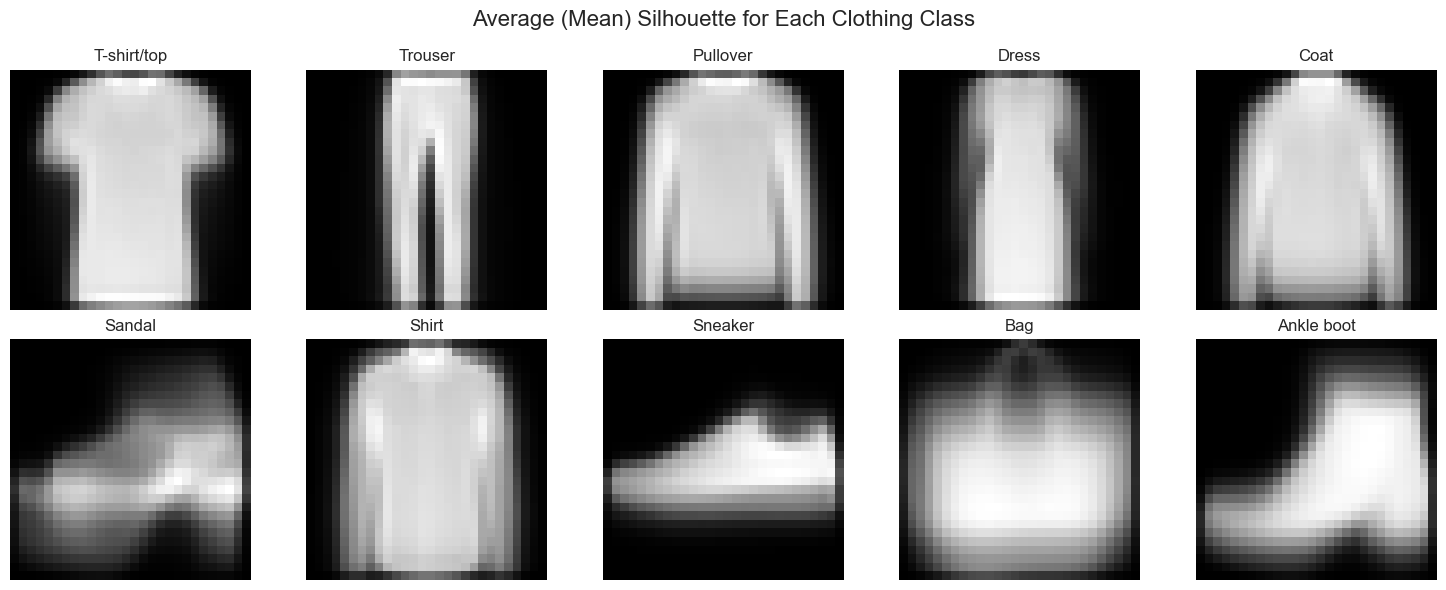

In [23]:
print("--- MEAN IMAGE REPRESENTATION ---")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Average (Mean) Silhouette for Each Clothing Class", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    # Extract all raw images corresponding to class 'i'
    class_images = X_train_raw[y_train_raw == i]
    
    # Calculate the mean across the sample axis (axis=0)
    mean_image = np.mean(class_images, axis=0).reshape(28, 28)
    
    # Plot the average image
    ax.imshow(mean_image, cmap='gray')
    ax.set_title(class_names[i], fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 4.3 Data Standardization for Dimensionality Reduction
Before applying any distance-based or variance-based dimensionality reduction algorithms, it is mathematically required to normalize the data. We scale the raw pixel intensities from `[0, 255]` to a strict `[0.0, 1.0]` range. This prevents numerical overflow and ensures computational stability across all 60,000 samples.

In [24]:
print("--- STANDARDIZING FULL DATASET ---")
# Scaling all 60,000 training samples
X_full_scaled = X_train_raw / 255.0

print(f"Scaled Data Shape: {X_full_scaled.shape}")
print(f"Max Value after scaling: {X_full_scaled.max()}")
print(f"Min Value after scaling: {X_full_scaled.min()}")

--- STANDARDIZING FULL DATASET ---
Scaled Data Shape: (60000, 784)
Max Value after scaling: 1.0
Min Value after scaling: 0.0


### 4.4 Principal Component Analysis (PCA)
PCA is a linear transformation algorithm that projects the 784-dimensional data into 2 dimensions while maximizing the variance (spread) of the data.

**Axis Interpretation:**
* **X-Axis (Principal Component 1):** Represents the direction in the original 784-dimensional space that captures the absolute maximum variance (the most significant global visual patterns, such as overall brightness or size of the clothing).
* **Y-Axis (Principal Component 2):** Represents the direction orthogonal (perpendicular) to PC1 that captures the second largest variance.
* *Note: The numerical values on these axes have absolute mathematical meaning; they are the exact projected coordinates along the eigenvectors.*

Calculating PCA on 60,000 samples...


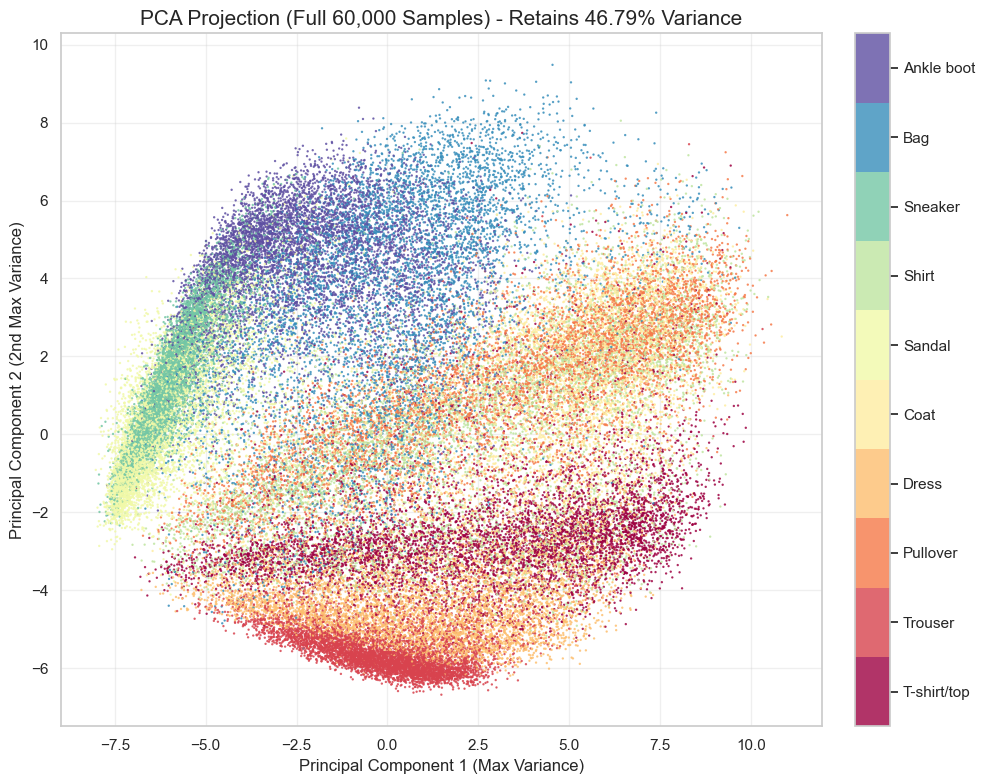

In [25]:
print("Calculating PCA on 60,000 samples...")
pca = PCA(n_components=2, random_state=42)
X_pca_full = pca.fit_transform(X_full_scaled)
pca_variance = pca.explained_variance_ratio_.sum()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_full[:, 0], X_pca_full[:, 1], 
                      c=y_train_raw, cmap='Spectral', alpha=0.8, s=0.5)

cbar = plt.colorbar(scatter, boundaries=np.arange(11)-0.5, fraction=0.046, pad=0.04)
cbar.set_ticks(np.arange(10))
cbar.ax.set_yticklabels(class_names)

plt.title(f"PCA Projection (Full 60,000 Samples) - Retains {pca_variance:.2%} Variance", fontsize=15)
plt.xlabel("Principal Component 1 (Max Variance)", fontsize=12)
plt.ylabel("Principal Component 2 (2nd Max Variance)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 t-SNE Projection
t-SNE is a non-linear technique designed to preserve local similarities. It calculates the probability of two points being neighbors in the high-dimensional space and tries to replicate that probability in the 2D space.

**Axis Interpretation:**
* **X-Axis & Y-Axis (t-SNE Dimension 1 & 2):** Unlike PCA, the specific numerical values (e.g., -50 or 100) on these axes are **meaningless** in a physical or absolute mathematical sense. They are merely an arbitrary coordinate system generated for visualization.
* *Note: Only the **relative distances** between clusters matter here. Items close together are structurally similar, while items far apart are structurally different.*

Calculating t-SNE on 60,000 samples... (Please be patient, this takes time)
t-SNE completed in 5.67 minutes!


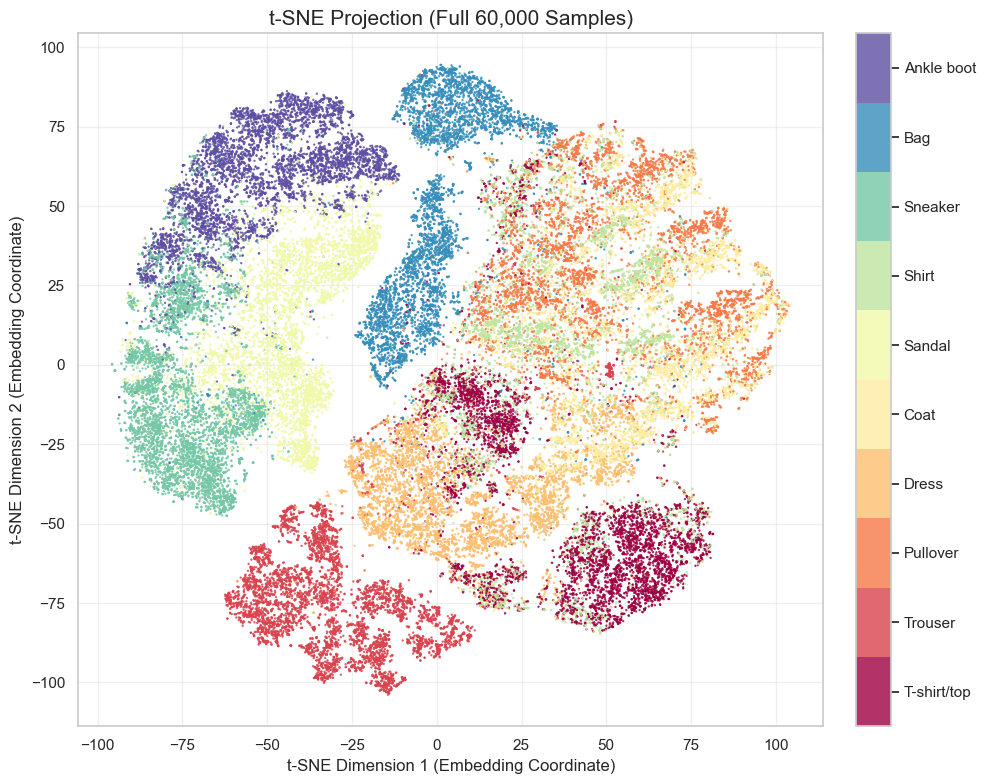

In [26]:
print("Calculating t-SNE on 60,000 samples... (Please be patient, this takes time)")
start_time = time.time()

tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne_full = tsne.fit_transform(X_full_scaled)
print(f"t-SNE completed in {(time.time() - start_time) / 60:.2f} minutes!")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne_full[:, 0], X_tsne_full[:, 1], 
                      c=y_train_raw, cmap='Spectral', alpha=0.8, s=0.5)

cbar = plt.colorbar(scatter, boundaries=np.arange(11)-0.5, fraction=0.046, pad=0.04)
cbar.set_ticks(np.arange(10))
cbar.ax.set_yticklabels(class_names)

plt.title("t-SNE Projection (Full 60,000 Samples)", fontsize=15)
plt.xlabel("t-SNE Dimension 1 (Embedding Coordinate)", fontsize=12)
plt.ylabel("t-SNE Dimension 2 (Embedding Coordinate)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.6 UMAP Projection
UMAP is a modern manifold learning technique that constructs a high-dimensional graph of the data and then optimizes a low-dimensional graph to be as structurally similar as possible. It is much faster than t-SNE and preserves global distances better.

**Axis Interpretation:**
* **X-Axis & Y-Axis (UMAP Dimension 1 & 2):** Similar to t-SNE, the axes represent an arbitrary embedding space. The exact coordinates carry no absolute physical meaning.
* *Note: UMAP preserves both local neighborhoods and global topological structure. Therefore, the empty space (distance) between clusters on these axes genuinely implies a high degree of dissimilarity between those clothing categories.*

Calculating UMAP on 60,000 samples...


c:\Users\thanh\miniconda3\envs\lab_fixed\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completed in 66.19 seconds!


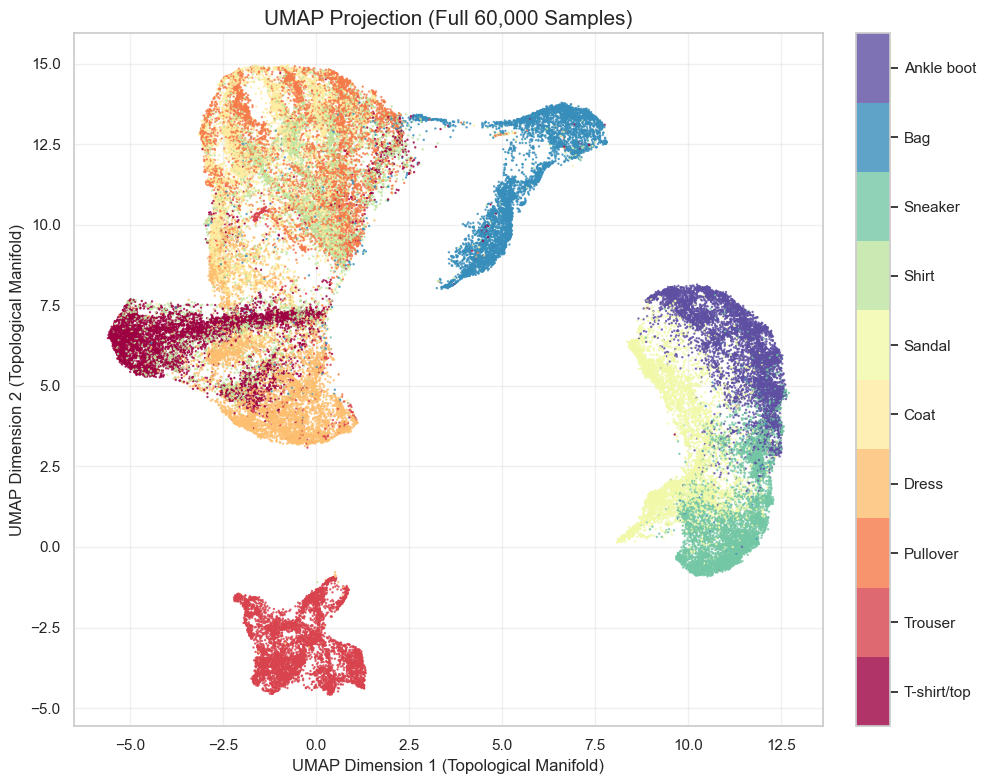

In [27]:
print("Calculating UMAP on 60,000 samples...")
start_time = time.time()

umap_reducer = umap.UMAP(
    n_neighbors=15, 
    min_dist=0.1, 
    n_components=2, 
    metric='euclidean', 
    random_state=42
)
X_umap_full = umap_reducer.fit_transform(X_full_scaled)
print(f"UMAP completed in {time.time() - start_time:.2f} seconds!")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_umap_full[:, 0], X_umap_full[:, 1], 
                      c=y_train_raw, cmap='Spectral', alpha=0.8, s=0.5)

cbar = plt.colorbar(scatter, boundaries=np.arange(11)-0.5, fraction=0.046, pad=0.04)
cbar.set_ticks(np.arange(10))
cbar.ax.set_yticklabels(class_names)

plt.title("UMAP Projection (Full 60,000 Samples)", fontsize=15)
plt.xlabel("UMAP Dimension 1 (Topological Manifold)", fontsize=12)
plt.ylabel("UMAP Dimension 2 (Topological Manifold)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.7 PyMDE (Minimum Distortion Embedding)
PyMDE embeds data by explicitly trying to minimize the distortion of distances between original nearest neighbors. It often results in very tightly packed, isolated clusters.

**Axis Interpretation:**
* **X-Axis & Y-Axis (PyMDE Dimension 1 & 2):** These are coordinates in the optimized embedding space. 
* *Note: The values themselves do not correlate to specific pixel features. The objective of these axes is purely to serve as a canvas where the geometric distortion (stretching or compressing of neighbor distances) is minimized.*

Calculating PyMDE on 60,000 samples...
Apr 18 05:10:51 PM: Computing 15-nearest neighbors, with max_distance=None
Apr 18 05:10:54 PM: Computing quadratic initialization.
PyMDE completed in 64.26 seconds!


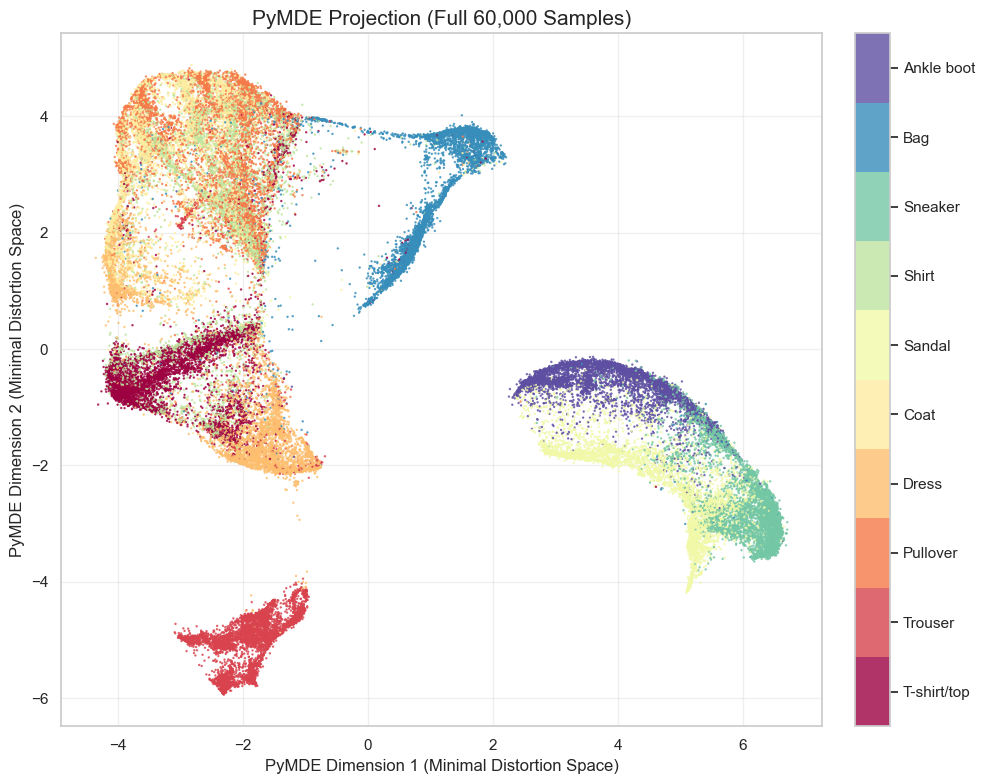

In [28]:
print("Calculating PyMDE on 60,000 samples...")
start_time = time.time()

mde_graph = pymde.preserve_neighbors(X_full_scaled, embedding_dim=2, verbose=True)
X_mde_full = mde_graph.embed()

if hasattr(X_mde_full, 'numpy'):
    X_mde_np = X_mde_full.numpy()
else:
    X_mde_np = X_mde_full
    
print(f"PyMDE completed in {time.time() - start_time:.2f} seconds!")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_mde_np[:, 0], X_mde_np[:, 1], 
                      c=y_train_raw, cmap='Spectral', alpha=0.8, s=0.5)

cbar = plt.colorbar(scatter, boundaries=np.arange(11)-0.5, fraction=0.046, pad=0.04)
cbar.set_ticks(np.arange(10))
cbar.ax.set_yticklabels(class_names)

plt.title("PyMDE Projection (Full 60,000 Samples)", fontsize=15)
plt.xlabel("PyMDE Dimension 1 (Minimal Distortion Space)", fontsize=12)
plt.ylabel("PyMDE Dimension 2 (Minimal Distortion Space)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Data Distribution (Train, Test)

### 5.1 Check Initial Data Distribution
We begin by calculating the class distribution of the original 60,000 training samples and 10,000 testing samples to ensure there is no class imbalance.

In [29]:
print("--- CHECK INITIAL DISTRIBUTION ---")

# Function to calculate and print the class distribution
def check_distribution(labels, set_name):
    unique, counts = np.unique(labels, return_counts=True)
    dist = dict(zip([class_names[i] for i in unique], counts))
    
    print(f"\nClass distribution in {set_name}:")
    for cls, count in dist.items():
        print(f" - {cls}: {count} ({count/len(labels):.2%})")
    return dist

# Check the distribution of the original Training and Testing sets
dist_train_raw = check_distribution(y_train_raw, "Original Train Set (60k)")
dist_test_raw = check_distribution(y_test_raw, "Original Test Set (10k)")

--- CHECK INITIAL DISTRIBUTION ---

Class distribution in Original Train Set (60k):
 - T-shirt/top: 6000 (10.00%)
 - Trouser: 6000 (10.00%)
 - Pullover: 6000 (10.00%)
 - Dress: 6000 (10.00%)
 - Coat: 6000 (10.00%)
 - Sandal: 6000 (10.00%)
 - Shirt: 6000 (10.00%)
 - Sneaker: 6000 (10.00%)
 - Bag: 6000 (10.00%)
 - Ankle boot: 6000 (10.00%)

Class distribution in Original Test Set (10k):
 - T-shirt/top: 1000 (10.00%)
 - Trouser: 1000 (10.00%)
 - Pullover: 1000 (10.00%)
 - Dress: 1000 (10.00%)
 - Coat: 1000 (10.00%)
 - Sandal: 1000 (10.00%)
 - Shirt: 1000 (10.00%)
 - Sneaker: 1000 (10.00%)
 - Bag: 1000 (10.00%)
 - Ankle boot: 1000 (10.00%)


### 5.2 Visualize Class Distributions
To provide clear evidence of data balance for the final report, we visualize the class counts across our two distinct datasets: Train, Test sets.

--- VISUALIZE DISTRIBUTIONS ---


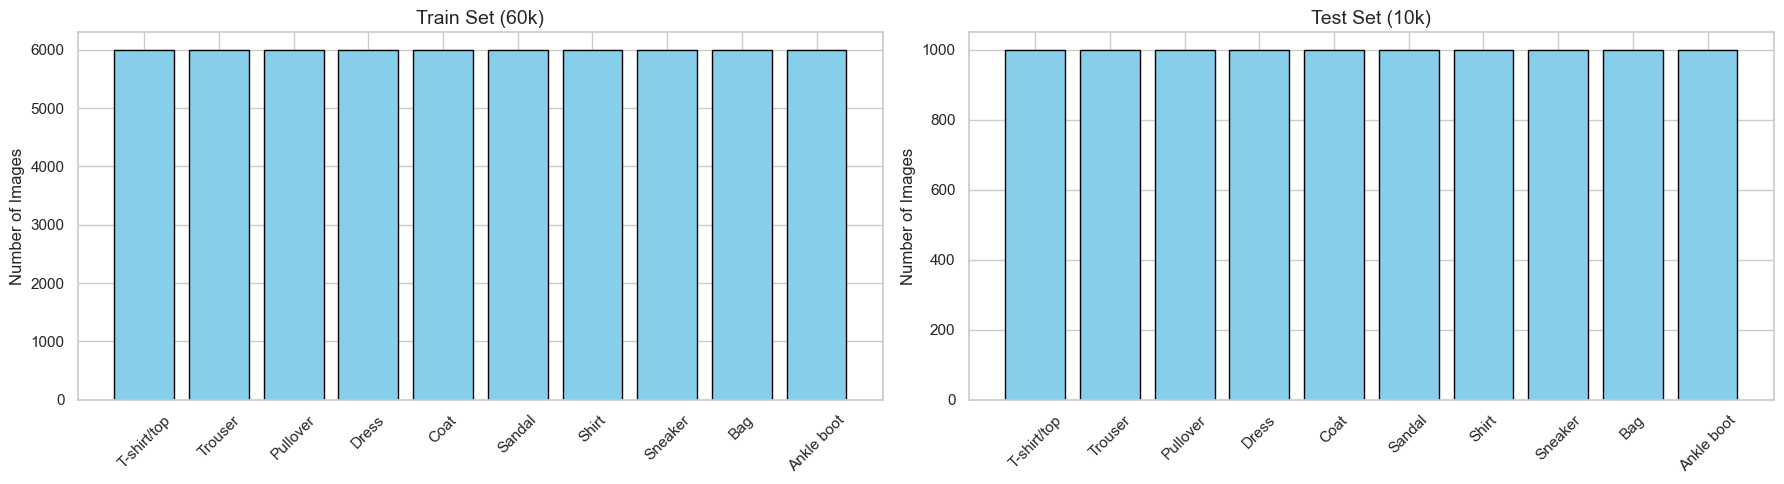

In [30]:
print("--- VISUALIZE DISTRIBUTIONS ---")

# Plot the distributions side-by-side for the final report
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
datasets = [y_train_raw, y_test_raw]
titles = ['Train Set (60k)', 'Test Set (10k)']

for i in range(2):
    unique, counts = np.unique(datasets[i], return_counts=True)
    
    # Plotting the bar chart for each dataset
    ax[i].bar([class_names[j] for j in unique], counts, color='skyblue', edgecolor='black')
    ax[i].set_title(titles[i], fontsize=14)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel('Number of Images')

plt.tight_layout()
plt.show()

### 5.3 Export Datasets to CSV
For reproducibility in future stages (e.g., model training), we serialize our NumPy arrays into CSV files. The resulting structure will contain 785 columns per row: the first column for the target label, followed by 784 pixel intensity values.

In [31]:
print("--- EXPORT TO CSV ---")

# Helper function to format and save the data
def save_to_csv(features, labels, filename):
    print(f"Preparing data for {filename}...")
    
    # Stack the label array as the first column, followed by the 784 pixel features
    data = np.column_stack((labels, features))
    
    # Generate column names: ['label', 'pixel1', 'pixel2', ..., 'pixel784']
    columns = ['label'] + [f'pixel{i}' for i in range(features.shape[1])]
    
    # Convert to pandas DataFrame and save to CSV
    df = pd.DataFrame(data, columns=columns)
    df.to_csv(filename, index=False)
    print(f"Successfully saved: {filename} (Shape: {df.shape})\n")

# Execute the saving process (This may take a few minutes depending on disk speed)
save_to_csv(X_train_raw, y_train_raw, "data/processed/fashion_mnist_train_60k.csv")
save_to_csv(X_test_raw, y_test_raw, "data/processed/fashion_mnist_test_10k.csv")

--- EXPORT TO CSV ---
Preparing data for data/processed/fashion_mnist_train_60k.csv...
Successfully saved: data/processed/fashion_mnist_train_60k.csv (Shape: (60000, 785))

Preparing data for data/processed/fashion_mnist_test_10k.csv...
Successfully saved: data/processed/fashion_mnist_test_10k.csv (Shape: (10000, 785))



### 5.4 Export Label Mapping
Since our CSV files store categorical labels as integers (0 to 9) to save space and optimize training, we must document the exact meaning of these numbers. We will export a JSON dictionary mapping these numerical keys to their corresponding human-readable clothing names. This ensures complete metadata persistence and makes future inference much easier.

**Fashion-MNIST Official Label Mapping:**
* `0` : T-shirt/top
* `1` : Trouser
* `2` : Pullover
* `3` : Dress
* `4` : Coat
* `5` : Sandal
* `6` : Shirt
* `7` : Sneaker
* `8` : Bag
* `9` : Ankle boot

In [32]:
print("--- EXPORT LABEL MAPPING (CSV) ---")

# Create a DataFrame containing the label IDs and their corresponding names
mapping_df = pd.DataFrame({
    'label_id': range(len(class_names)),
    'class_name': class_names
})

# Save the DataFrame to a CSV file
mapping_filename = "data/processed/labels.csv"
mapping_df.to_csv(mapping_filename, index=False)

print(f"Successfully saved mapping to: {mapping_filename}")
print("\nMapping Preview:")
display(mapping_df)

--- EXPORT LABEL MAPPING (CSV) ---
Successfully saved mapping to: data/processed/labels.csv

Mapping Preview:


,label_id,class_name
0,0,T-shirt/top
1,1,Trouser
2,2,Pullover
3,3,Dress
4,4,Coat
5,5,Sandal
6,6,Shirt
7,7,Sneaker
8,8,Bag
9,9,Ankle boot


## 6. Final Conclusions

Based on the statistical summaries and the four dimensionality reduction visualizations (PCA, t-SNE, UMAP, and PyMDE), we can draw the following professional conclusions to finalize the EDA phase:

**Exceptional Data Integrity and Quality:**
- The dataset is remarkably clean, with zero missing values, zero duplicate rows, and zero completely blank images.
- Pixel intensities strictly adhere to the expected [0, 255] range. 

**Pixel Sparsity and Global Statistics:**
- The Global Mean Intensity of 72.94 (on a 255 scale) suggests significant "sparsity." 
- Most pixels represent the black background (value 0), while information is concentrated in centered, high-contrast objects.
- A high Standard Deviation of 90.02 indicates strong contrast between the clothing items and the background, which is ideal for feature extraction and edge detection.

**Evidence of Non-Linear Complexity:**
- The PCA Projection only retained 46.79% of the variance in 2 dimensions and failed to clearly separate classes. 
- This confirms that the relationships between pixels are highly non-linear.
- The success of t-SNE, UMAP, and PyMDE in forming distinct clusters validates that the data exists on a complex, high-dimensional manifold.

This justifies the use of non-linear classifiers like Random Forest (RF), Support Vector Machines (SVM), or Multi-Layer Perceptrons (MLP).


**Class Separability and Topological Bottlenecks:**

* **High-Performing Clusters:**
    - Classes such as Trouser (1) and Bag (8) are consistently isolated across all visualizations. 
    - We expect the model to achieve near-perfect accuracy on these categories.

* **The "Upper-Body" Manifold:**
    - A major overlapping region exists between Shirt (6), T-shirt/top (0), Pullover (2), and Coat (4).
    - Because these items share nearly identical silhouettes (torso + sleeves), they represent the primary "bottleneck" for classification.

Distinguishing between them will require models capable of learning fine-grained textures (e.g., buttons, collars, or fabric density).